# Laboratorio 1
**Redes Neuronales para Lenguaje Natural, 2025**

En este laboratorio construiremos analizadores de sentimiento de tres clases (positivo, negativo, neutro) en textos que muestran opiniones, con el objetivo de comparar distintas técnicas de representación de los textos y utilizarlas para alimentar un modelo de redes neuronales.

**Entrega: 9 de octubre de 2025**

**Formato: notebook de Python (.ipynb)**

**No olvidar mantener todas las salidas de cada región de código en el notebook!**

---



## 0. Preparación del entorno

Comenzamos con algunos imports y definiciones.

In [101]:
! pip install --upgrade gensim


import torch
import gensim
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

POLARITY_LABELS = ['Neg','Pos','Neu']
POLARITY_ID = {p:i for (i,p) in enumerate(POLARITY_LABELS)}

In [102]:
POLARITY_ID

{'Neg': 0, 'Pos': 1, 'Neu': 2}

Descargamos los datos de textos de prensa, anotados con una de las siguientes clases: Pos, Neg,Neu. Por más información sobre el dataset, consulte [aquí](https://github.com/pln-fing-udelar/pln-inco-resources/tree/master/sentiment/corpusAnalisisSentimientosEsp)

In [103]:
! wget https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/sentiment/corpusAnalisisSentimientosEsp/prensaUyUnaClase.csv

--2026-05-18 23:20:54--  https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/sentiment/corpusAnalisisSentimientosEsp/prensaUyUnaClase.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 216401 (211K) [text/plain]
Saving to: ‘prensaUyUnaClase.csv.3’

prensaUyUnaClase.cs 100%[===================>] 211.33K  --.-KB/s    in 0.01s   

2026-05-18 23:20:54 (15.0 MB/s) - ‘prensaUyUnaClase.csv.3’ saved [216401/216401]



Cargamos el dataset en un dataframe de pandas y generamos conjuntos de entrenamiento, desarrollo y testeo.
Este dataset está compuesto por textos con opiniones. Para cada opinión tenemos el texto, un campo que no utilizaremos, y una categoría, que puede ser: Pos, Neg, o Neutro (indicando su polaridad).

In [104]:
from sklearn.model_selection import train_test_split

dataset_df = pd.read_csv('./prensaUyUnaClase.csv', header=None)
dataset_df.columns = ['text', 'extra', 'polarity']

# Dividimos train y test
temp_df, test_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

# Separamos conjunto de validación
train_df, dev_df = train_test_split(temp_df, test_size=0.2, random_state=42)

print("Training set size:", len(train_df))
print("Development set size:", len(dev_df))
print("Test set size:", len(test_df))

display(dataset_df.iloc[0].text)
display(dataset_df.iloc[0].polarity)





Training set size: 806
Development set size: 202
Test set size: 253


'Según Batlle , esas palabras " son palabras muy ilustrativas en cuanto a el sentimiento que ha sido hasta ahora el que ha prevalecido en el Uruguay , un sentimiento de tolerancia , un sentimiento de comprensión de la situación de el otro "'

'Pos'

En este laboratorio utilizaremos el texto como entrada (columna "text"), y el valor a predecir será la polaridad (columna "polarity").

Imprimimos algunos textos de ejemplo y sus categorías, y luego imprimimos la cantidad de ejemplos de las tres clases en las tres particiones.

In [105]:
train_text = train_df.loc[:,'text'].to_numpy()
dev_text = dev_df.loc[:,'text'].to_numpy()
test_text = test_df.loc[:,'text'].to_numpy()

train_labels = np.array([POLARITY_ID[l] for l in train_df.loc[:,'polarity']])
dev_labels = np.array([POLARITY_ID[l] for l in dev_df.loc[:,'polarity']])
test_labels = np.array([POLARITY_ID[l] for l in test_df.loc[:,'polarity']])

print(train_text[121])
print(POLARITY_LABELS[train_labels[121]])

print(train_text[27])
print(POLARITY_LABELS[train_labels[27]])

print(train_text[755])
print(POLARITY_LABELS[train_labels[755]])

print(*POLARITY_LABELS, sep='\t')
print(*np.bincount(train_labels), sep='\t')
print(*np.bincount(dev_labels), sep='\t')
print(*np.bincount(test_labels), sep='\t')


Temas Deudas por vivienda Durazno | Víctor D. rodríguez A partir de la próxima semana los residentes de las viviendas podrán concurrir a la oficina local de la ANV para acordar la forma de pago de la deuda , dijo la presidenta
Neu
Astori consideró por otra parte que el documento presentado por las cámaras empresariales con aportes por la pérdida de competitividad es " duro e injusto "
Neg
" Es la satisfacción de ver el trabajo de mi hijo Horacio , que conoce mucho de Criollos y ha hecho una selección fantástica que ha dado sus resultados " , aseguró Horacio Castells Montes
Pos
Neg	Pos	Neu
336	259	211
82	62	58
114	80	59


In [106]:
print(train_text[1])
print(train_labels[1])

" Es oportuno poner a consideración la oferta fruto de el trabajo de 3 décadas de selección en Polled Hereford , siempre comprando los mejores padres " , dijo el propio Balles
1


## Parte 1

Utilizando pytorch, construir un clasificador tipo Multi-Layered Perceptron (MLP) que clasifique los textos según su sentimiento.
En esta parte, se debe utilizar una representación tipo **bag-of-words (BOW)** para los tweets, la cual se utilizará como entrada de la red.

Puede probar realizar diferentes alternativas dentro de la representación BOW, por ejemplo considerar o no mayúsculas y minúsculas, descartar palabras con listas de stop words, usar N-gramas de orden mayor en vez de palabras simples, o utilizar tf-idf

**Sugerencias:**
* Utilizar la clase CountVectorizer de sklearn
* Limitar el número máximo de features para no quedarse sin memoria
* Reducir la dimensionalidad del vector utilizando, por ejemplo, SVD

In [107]:
from sklearn.feature_extraction.text import CountVectorizer
import torch.nn

max_features = 5000
hidden_dim = 500
epochs = 10

vectorizer = CountVectorizer(max_features=max_features)

train_bow = vectorizer.fit_transform(train_text)
dev_bow = vectorizer.transform(dev_text)
test_bow = vectorizer.transform(test_text)

train_bow_tensor = torch.tensor(train_bow.toarray(), dtype=torch.float32)
dev_bow_tensor = torch.tensor(dev_bow.toarray(), dtype=torch.float32)
test_bow_tensor = torch.tensor(test_bow.toarray(), dtype=torch.float32)

train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
dev_labels_tensor = torch.tensor(dev_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

mlp = torch.nn.Sequential(
    torch.nn.Linear(max_features, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, 3)
)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

for epoch in range(epochs):
    # forward
    y_pred = mlp(train_bow_tensor)
    loss = loss_fn(y_pred, train_labels_tensor)

    # backward
    optimizer.zero_grad()
    loss.backward()

    # actualizamos
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Epoch 1/10, Loss: 1.0961166620254517
Epoch 2/10, Loss: 1.050906777381897
Epoch 3/10, Loss: 1.0092114210128784
Epoch 4/10, Loss: 0.9650403261184692
Epoch 5/10, Loss: 0.9174460172653198
Epoch 6/10, Loss: 0.8669498562812805
Epoch 7/10, Loss: 0.814217209815979
Epoch 8/10, Loss: 0.7600675225257874
Epoch 9/10, Loss: 0.7053450345993042
Epoch 10/10, Loss: 0.6509421467781067


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1. Incluya también una matriz de confusión.

---



En este primer experimento utilizamos una representación bag-of-words (BOW) con un máximo de 5000 características. Entrenamos un MLP con una capa oculta de 500 neuronas y activación ReLU.

Evaluamos este primer modelo en el conjunto de desarrollo.

In [108]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
from torch import no_grad

mlp.eval() # modo de evaluacion
with no_grad(): # desactiva calculo de gradiente
  dev_outputs = mlp(dev_bow_tensor)
  _, dev_preds = torch.max(dev_outputs, 1)

dev_preds_np = np.array(dev_preds)

# Cálculo de metricas
accuracy = accuracy_score(dev_labels, dev_preds_np)
precision, recall, f1, _ = precision_recall_fscore_support(dev_labels, dev_preds_np, average='macro')
conf_matrix = confusion_matrix(dev_labels, dev_preds_np)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1 Score: {f1:.4f}")

Accuracy: 0.4802
Macro Precision: 0.5543
Macro Recall: 0.4329
Macro F1 Score: 0.3915


Dado que los resultados no son buenos, realizamos un segundo experimento. En éste probamos con tf-idf para la representación de los tweets, n-gramas de orden mayor, pasamos todo a minúsculas y quitamos outliers o hiperfrecuencias.

In [109]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
import random

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seeds(42)

# Definimos esta variable para probar con stopwords después, pero finalmente decidimos dejarla en None.
stop_words = None

tfidf_params = dict(
    ngram_range=(1,2),
    lowercase=True,
    max_features=10000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    stop_words = stop_words,
)

# Nuevo vectorizador utilizando los parámetros definidos previamente:
vectorizer = TfidfVectorizer(**tfidf_params)
X_train = vectorizer.fit_transform(train_text)
X_dev   = vectorizer.transform(dev_text)
X_test  = vectorizer.transform(test_text)

# Mismo procedimiento que en el primer experimento para pasar a tensores:
X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_dev_t   = torch.tensor(X_dev.toarray(),   dtype=torch.float32)
X_test_t  = torch.tensor(X_test.toarray(),  dtype=torch.float32)

y_train_t = torch.tensor(train_labels, dtype=torch.long)
y_dev_t   = torch.tensor(dev_labels,   dtype=torch.long)
y_test_t  = torch.tensor(test_labels,  dtype=torch.long)

In [110]:
# Entrenamiento con mini batches.
batch_size = 64

train_ds = TensorDataset(X_train_t, y_train_t)
dev_ds   = TensorDataset(X_dev_t,   y_dev_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=batch_size, shuffle=False)

# Observamos que en experimentos anteriores se predecía mucho la clase mayoritaria, así que agregamos pesos.
class_counts = np.bincount(train_labels)
class_weights = (1.0 / (class_counts + 1e-9)) * (len(train_labels) / len(class_counts))
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class counts:", class_counts, " -> Weights:", class_weights.numpy())

Class counts: [336 259 211]  -> Weights: [0.79960316 1.037323   1.2733017 ]


In [111]:
# Definición del MLP

input_dim = X_train_t.shape[1]
# Una capa oculta con 256 neuronas
hidden_dims = [256]
# Dropout con probabilidad 0.2
dropouts = [0.2]

# Definimos una clase para poder guardar/restaurar el mejor estado
class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden_dims, dropouts, n_classes):
        super().__init__()
        layers = []
        prev = input_dim
        for h, d in zip(hidden_dims, dropouts):
            layers.append(torch.nn.Linear(prev, h))
            layers.append(torch.nn.ReLU())
            layers.append(torch.nn.Dropout(d))
            prev = h
        layers.append(torch.nn.Linear(prev, n_classes))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

set_seeds(42)
mlp2 = MLP(input_dim, hidden_dims, dropouts, n_classes=3)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(mlp2.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 30
patience = 4
best_f1 = -1
best_state = None
patience_ctr = 0

for epoch in range(1, epochs+1):
    mlp2.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb, yb
        optimizer.zero_grad()
        logits = mlp2(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_ds)
    # Evaluación en dev
    mlp2.eval()
    dev_preds = []
    dev_true  = []
    with torch.no_grad():
        for xb, yb in dev_loader:
            xb = xb
            logits = mlp2(xb)
            pred = logits.argmax(dim=1).numpy()
            dev_preds.append(pred)
            dev_true.append(yb.numpy())
    dev_preds = np.concatenate(dev_preds)
    dev_true  = np.concatenate(dev_true)

    accuracy = accuracy_score(dev_true, dev_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(dev_true, dev_preds, average='macro', zero_division=0)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}, Accuracy = {accuracy:.4f}, MacroF1={f1:.4f}")
    # Early stopping por Macro-F1
    if f1 > best_f1:
        best_f1 = f1
        best_state = {k: v.clone() for k, v in mlp2.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping: no mejora de Macro-F1.")
            break

# Restaurar mejor estado
if best_state is not None:
    mlp2.load_state_dict({k: v for k, v in best_state.items()})

Epoch 2/30, Loss: 1.0941907167434692, Accuracy = 0.4554, MacroF1=0.4529
Epoch 3/30, Loss: 1.0614161491394043, Accuracy = 0.4554, MacroF1=0.4545
Epoch 4/30, Loss: 1.0148110389709473, Accuracy = 0.5149, MacroF1=0.5109
Epoch 5/30, Loss: 0.9161750078201294, Accuracy = 0.5099, MacroF1=0.5071
Epoch 6/30, Loss: 0.8347921967506409, Accuracy = 0.5000, MacroF1=0.4965
Epoch 7/30, Loss: 0.6213667392730713, Accuracy = 0.5248, MacroF1=0.5218
Epoch 8/30, Loss: 0.555519163608551, Accuracy = 0.4950, MacroF1=0.4876
Epoch 9/30, Loss: 0.4089999198913574, Accuracy = 0.4901, MacroF1=0.4836
Epoch 10/30, Loss: 0.2861456274986267, Accuracy = 0.4901, MacroF1=0.4838
Epoch 11/30, Loss: 0.24520866572856903, Accuracy = 0.4752, MacroF1=0.4658
Early stopping: no mejora de Macro-F1.


In [112]:
# Reporte final en dev (con matriz de confusión)
mlp2.eval()
with torch.no_grad():
    logits = mlp2(X_dev_t)
    dev_preds_final = logits.argmax(dim=1).numpy()

# Cálculo de metricas
accuracy = accuracy_score(dev_labels, dev_preds_final)
precision, recall, f1, _ = precision_recall_fscore_support(dev_labels, dev_preds_final, average='macro', zero_division=0)
conf_matrix = confusion_matrix(dev_labels, dev_preds_final)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
conf_matrix

Accuracy: 0.5248
Macro Precision: 0.5303
Macro Recall: 0.5278
Macro F1 Score: 0.5218


array([[40, 21, 21],
       [ 8, 38, 16],
       [12, 18, 28]])

**Descripción del modelo**:

En esta sección construimos un primer modelo `mlp` y un segundo modelo `mlp2` que obtuvimos a partir de pequeñas mejoras en el primero.

**Representación de los textos:**
Se utiliza `TfidfVectorizer` con los siguientes parámetros:
- `ngram_range=(1,2)` para incluir unigramas y bigramas.
- `lowercase=True` para ignorar mayúsculas/minúsculas.
- `min_df=3` y `max_df=0.9` para eliminar palabras muy raras o extremadamente frecuentes.
- `max_features=10000` para limitar la dimensionalidad.
- `sublinear_tf=True` para aplicar suavizado logarítmico a las frecuencias.

**Arquitectura de modelo:**
- Entrada: vector TF-IDF de hasta 10 000 dimensiones.
- Capa oculta: Una capa oculta de 256 neuronas.
- Dropout: Se aplica dropout con probabilidad 0.2 después de la capa oculta para evitar sobreajuste.
- Activación: Función ReLU después de la capa oculta.
- Salida: Capa lineal con 3 unidades, correspondiente a las clases de polaridad (Positivo, Negativo, Neutro).

En esta sección probamos con diferentes cantidades de capas y neuronas por capa y observamos que al aumentar estos números, el desempeño del modelo empeoraba. Consideramos que un ajuste en la cantidad de épocas podría mejorar los resultados, aunque logramos llegar a valores óptimos.

**Técnicas utilizadas**:

- Entrenamiento con mini batches: Se utiliza DataLoader para entrenar el modelo en mini batches de tamaño 64, lo que mejora la estabilidad y eficiencia del entrenamiento.
- Función de pérdida: CrossEntropyLoss ponderada según la frecuencia de las clases para balancear el dataset.
- Optimización: Se utiliza el optimizador Adam con tasa de aprendizaje $1e^{-3}$ y weight decay = $1e^{-4}$.
- Early stopping: Se detiene el entrenamiento si no mejora la macro-F1 en varias épocas consecutivas.

**Evaluación:**
- Se reportan métricas de accuracy, macro-precision, macro-recall y macro-F1.
- Además se muestra la matriz de confusión.

**Resultados**:

- El modelo logra una capacidad de clasificación aceptable, demostrando una mejora significativa respecto al primer experimento usando BOW, especialmente cuando se ajustan los hiperparámetros.
- Las métricas de evaluación nos muestran que funciona mejor que un clasificador aleatorio, lo cual sería el benchmark, pero no superamos el 52% de aciertos.
- La matriz de confusión muestra que la clase Neutro es la más difícil de predecir.

## Parte 2

Utilizando pytorch, construir un clasificador tipo Multi-Layered Perceptron (MLP) que clasifique los textos según su polaridad.
En esta parte, se debe utilizar una representación tipo **centroide de word embeddings** para los tweets, la cual se utilizará como entrada de la red.

Puede probar realizar diferentes alternativas dentro de la representación con word embeddings, por ejemplo considerar o no mayúsculas y minúsculas, o descartar palabras con listas de stop words.

**Sugerencias:**
* Puede utilizar uno de los embeddings que vimos en el taller en clase
* O puede bajar alguna otra colección de embeddings, pero no entrene sus propios embeddings!

---

Las siguientes celdas siguen el segundo HandsOn trabajado en clase para importar los embeddings y construir el tokenizador y centroide de embeddings.

In [113]:
# Embeddings del Spanish Billion Words extraídos del taller en clase
# Sitio oficial de la Universidad Nacional de Córdoba
! wget https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz

--2026-05-18 23:21:12--  https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz
Resolving cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)... 200.16.17.55
Connecting to cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)|200.16.17.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1123304474 (1.0G) [application/x-gzip]
Saving to: ‘SBW-vectors-300-min5.bin.gz.3’

SBW-vectors-300-min 100%[===================>]   1.05G  20.0MB/s    in 57s     

2026-05-18 23:22:10 (19.0 MB/s) - ‘SBW-vectors-300-min5.bin.gz.3’ saved [1123304474/1123304474]



In [114]:
# Abrirlos con la biblioteca de embeddings gensim
from gensim.models import KeyedVectors
wv = KeyedVectors.load_word2vec_format("./SBW-vectors-300-min5.bin.gz", binary=True)
print(wv.vectors.shape)
embeddings_size = wv.vectors.shape[1]

(1000653, 300)


Extraído del HandsOn:

"Para utilizar los textos del corpus en un clasificador, debemos realizar las siguientes acciones:

1.   Preprocesar los textos (p.e. tokenizar)
2.   Transformarlos a una representación vectorial (p.e. centroide)
3.   Obtener los labels del corpus (que son valores 0 o 1) como array de numpy."

(En el punto 3. tendremos valores Neg, Pos y Neu (0, 1, 2) en vez de 0 o 1)


In [115]:
# 1) Tokenizar el texto utilizando el tokenizador de tweets de la biblioteca NLTK
from nltk.tokenize import TweetTokenizer
tk = TweetTokenizer()

def tokenize(t):
  return tk.tokenize(t)

In [116]:
train_tokens = [tokenize(t) for t in train_text]
dev_tokens = [tokenize(t) for t in dev_text]
test_tokens = [tokenize(t) for t in test_text]

print(len(train_tokens))
print(len(train_tokens[0]))
print(train_tokens[:3])

806
42
[['La', 'ONG', 'Tierra', 'de', 'Hombres', 'anunció', 'el', 'lunes', 'que', 'ha', 'identificado', 'a', 'más', 'de', '1.0', '"', 'depredadores', '"', 'sexuales', 'haciendo', 'se', 'pasar', 'por', 'una', 'niña', 'filipina', 'virtual', 'de', '10', 'años', ',', 'dispuestos', 'a', 'pagar', 'por', 'ver', 'la', 'en', 'actos', 'sexuales', 'por', 'cámara'], ['"', 'Es', 'oportuno', 'poner', 'a', 'consideración', 'la', 'oferta', 'fruto', 'de', 'el', 'trabajo', 'de', '3', 'décadas', 'de', 'selección', 'en', 'Polled', 'Hereford', ',', 'siempre', 'comprando', 'los', 'mejores', 'padres', '"', ',', 'dijo', 'el', 'propio', 'Balles'], ['presidente', 'planteó', 'que', 'no', 'hay', 'que', 'dar', 'señales', 'a', 'los', 'criadores']]


En la siguiente celda de código se incluye un código comentado que sirvió para experimentar con técnicas de pooling y stopwords, pero no aportó mejoras significativas. Explicaremos esto mejor al final de la sección.

In [117]:
# 2) Transformarlos a una representación vectorial

# Primero implementamos la función 'get_vector' que recibe una palabra y devuelve su vector
# Siempre devuelve la representación en minúscula
# Si es un símbolo de puntuación, devuelve un vector especial creado específicamente
# Si comienza en un número, devuelve la representación del cinco

import string
import random

def l2norm(v, eps=1e-12):
    n = norm(v)
    return v / (n + eps)

# En caso de querer usar stop words
def should_keep(token, stop_words_set=None):
    if stop_words_set is None:
        return True
    return token.lower() not in stop_words_set

punct_vector= np.random.rand(embeddings_size)
num_vector = wv['cinco']

def get_vector(word, wv):
  if word in wv:
    return wv[word]
  elif word.lower() in wv:
    return wv[word.lower()]
  elif word[0] in string.punctuation:
    return punct_vector
  elif word[0] in [0,1,2,3,4,5,6,7,8,9]:
    return num_vector
  else:
    return None

# Definimos dos funciones para aplicar pooling que devuelve un vector representativo del tweet,
# calculando el promedio o máximo de los embeddings de sus palabras.

# Average pooling
def pooling_mean(tokens, wv, stop_words=None, norm_words=True, norm_sent=True):
    vs = []
    for t in tokens:
        if not should_keep(t, stop_words):
            continue
        v = get_vector(t, wv)
        if v is None:
            continue
        vs.append(l2norm(v) if norm_words else v)
    if not vs:
        return np.zeros(wv.vector_size, dtype=np.float32)
    sent = np.mean(vs, axis=0)
    return (l2norm(sent) if norm_sent else sent).astype(np.float32)

# Max pooling
def pooling_max(tokens, wv, stop_words=None, norm_words=True):
    vs = []
    for t in tokens:
        if not should_keep(t, stop_words):
            continue
        v = get_vector(t, wv)
        if v is None:
            continue
        vs.append(l2norm(v) if norm_words else v)
    if not vs:
        return np.zeros(wv.vector_size, dtype=np.float32)
    M = np.stack(vs)
    max_v = np.max(M, axis=0)
    return max_v.astype(np.float32)

# Luego, a partir de una lista de tweets la función 'get_matrix' devuelve
# una matriz con un vector corresondiente a cada tweet
# Para ello recorre los tweets y obtiene la representación de cada token
# Finalmente, promedia sus valores en un único embedding final

def get_matrix(tokens):
  found = 0
  not_found = 0
  zero = np.zeros(embeddings_size)
  vectors = []
  for toks in tokens:
    vs = []
    for t in toks:
      v = get_vector(t, wv)
      if v is not None:
        found += 1
        vs.append(v)
      else:
        not_found += 1
    if len(vs) > 0:
        avg_vector = np.mean(vs, axis=0)
        vectors.append(avg_vector)
    else:
        vectors.append(zero)
  return np.array(vectors)

# Si usamos pooling y stop words, esta función quedaría así:
# def get_matrix(tokens_list, wv, pooling="mean", stop_words=None):
#     if pooling == "mean":
#         M = np.stack([pooling_mean(toks, wv, stop_words=stop_words) for toks in tokens_list])
#         return M.astype(np.float32)
#     elif pooling == "max":
#         M = np.stack([pooling_max(toks, wv, stop_words=stop_words) for toks in tokens_list])
#         return M.astype(np.float32)
#     else:
#         raise ValueError(f"Pooling no soportado: {pooling}. Usar 'mean' o 'max'.")

# Y después la usaríamos así:
# train_emb = torch.tensor(get_matrix(train_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)
# dev_emb = torch.tensor(get_matrix(dev_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)
# test_emb = torch.tensor(get_matrix(test_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)

In [118]:
train_emb = torch.tensor(get_matrix(train_tokens), dtype=torch.float)
dev_emb = torch.tensor(get_matrix(dev_tokens), dtype=torch.float)
test_emb = torch.tensor(get_matrix(test_tokens), dtype=torch.float)

print(train_emb.shape)
print(dev_emb.shape)
print(test_emb.shape)

torch.Size([806, 300])
torch.Size([202, 300])
torch.Size([253, 300])


In [119]:
# 3) Obtener los labels de los conjuntos, ya que los obtuvimos previamente en la parte 0 simplemente los volvemos a invocar

print(*POLARITY_LABELS, "Total", sep='\t')
print(*np.bincount(train_labels), train_labels.size, sep='\t')
print(*np.bincount(dev_labels), dev_labels.size, sep='\t')
print(*np.bincount(test_labels), test_labels.size, sep='\t')

Neg	Pos	Neu	Total
336	259	211	806
82	62	58	202
114	80	59	253


Ahora pasamos a declarar la red MLP que utilizaremos para clasificar los tweets.
Recibe como entrada la dimensión de input de la red, que es igual al tamaño de los embeddings, siempre le pasaremos de entrada la variable embeddings_size, la cuál dependerá de la representación de embeddings que usemos. También recibe el tamaño de la capa oculta con la cuál podremos experimentar variantes de la misma, y finalmente la dimensión de la capa de salida, que siempre coincidirá con la cantidad de clases posibles a clasificar, en este caso 3.\
\
Entonces, tanto el tamaño de la capa oculta como la cantidad de capas serán hiperparámetros que consideraremos para experimentar en la Parte 3. Para la arquitectura de la Parte 2 usaremos 150 nodos en la capa oculta (cantidad igual a la mitad del tamaño de los embeddings del Spanish Billion Word Corpus) y una sola capa oculta.\
\
Por último, también habilitaremos el uso de la técnica de Dropout en la implementación de la arquitectura, aunque evaluaremos su uso más adelante en la Parte 3. Para la Parte 2 estará deshabilitado, por lo que el parámetro toma el valor 0.0 por defecto.

In [120]:
class MLP3(torch.nn.Module):
  def __init__(self, dim_input, dim_hidden, dim_out, second_layer, dropout = 0.0):
    super(MLP3, self).__init__()
    self.linear_1 = torch.nn.Linear(dim_input, dim_hidden)
    self.ReLU = torch.nn.ReLU()
    self.out = torch.nn.Linear(dim_hidden, dim_out)
    if dropout > 0:
      self.dropout = torch.nn.Dropout(dropout)
    if second_layer:
      # Si 'second_layer' es True, se agrega una segunda capa oculta idéntica a la primera.
      self.linear_2 = torch.nn.Linear(dim_hidden, dim_hidden)
      self.net = torch.nn.Sequential(self.linear_1, self.ReLU, self.linear_2, self.ReLU, self.out)
      if dropout > 0:
        self.dropout2 = torch.nn.Dropout(dropout)
    else:
      self.net = torch.nn.Sequential(self.linear_1, self.ReLU, self.out)

  def forward(self, X):
    return self.net(X)


La siguiente celda de código incluye un código comentado que sirvió para experimentar con diferentes funciones de activación, pero no aportó mejoras significativas. Nuevamente, explicaremos esto mejor al final de la sección.

In [121]:
# Idea para probar con diferentes funciones de activación, para evitar tener diferentes clases. Por defecto usa ReLU.

# def build_mlp(dim_input, dim_hidden, dim_out, second_layer=True, dropout=0.0, activation='relu'):
#     activations = {
#         'relu': torch.nn.ReLU(),
#         'tanh': torch.nn.Tanh(),
#         'sigmoid': torch.nn.Sigmoid(),
#         'gelu': torch.nn.GELU(),
#         'leaky_relu': torch.nn.LeakyReLU()
#     }
#     act_function = activations.get(activation, torch.nn.ReLU())
#     layers = []
#     layers.append(torch.nn.Linear(dim_input, dim_hidden))
#     layers.append(act_function)
#     if dropout and dropout > 0.0:
#         layers.append(torch.nn.Dropout(dropout))
#     if second_layer:
#         layers.append(torch.nn.Linear(dim_hidden, dim_hidden))
#         layers.append(act_function)
#         if dropout and dropout > 0.0:
#             layers.append(torch.nn.Dropout(dropout))
#     layers.append(torch.nn.Linear(dim_hidden, dim_out))
#     return torch.nn.Sequential(*layers)

Con la red pronta, definimos una función "evaluate" (inspirada en el tercer HandsOn) que se encarga de evaluar la red según un conjunto de datos brindados.

In [122]:
def evaluate(net, dataset):
    with torch.no_grad():
      tag_scores = net(dataset)
      _, indices = torch.max(tag_scores, 1)
    return indices

Finalmente, con la red y función de evaluación definidas, pasamos a la etapa de entrenamiento y evaluación. Primero haremos una ejecución inicial sin entrenar como línea base para luego comparar con el modelo entrenado.

In [123]:
set_seeds(42)
mlp3 = MLP3(dim_input=embeddings_size, dim_hidden=150, dim_out=len(POLARITY_LABELS), second_layer=False)

predicted_labels = evaluate(mlp3, dev_emb)
results = precision_recall_fscore_support(dev_labels, predicted_labels, average='macro', zero_division=0.0)
accuracy = accuracy_score(dev_labels, predicted_labels)

print("Accuracy: ", accuracy)
print("Precision: ", results[0])
print("Recall: ", results[1])
print("F1-score: ", results[2])

Accuracy:  0.30198019801980197
Precision:  0.1011608623548922
Recall:  0.3279569892473118
F1-score:  0.15462610899873258


Luego de observar los resultados de la red sin entrenar, pasaremos a definir las funciones y parámetros necesarios para el entrenamiento.

Vale la pena comentar que el número de épocas a utilizar también puede ser considerado como un hiperparámetro. Para la Parte 2 decidimos quedarnos con 35 épocas al entrenar con el conjunto entero de train. Elegimos este número luego de probar varias ejecuciones con diferentes valores. En la Parte 3 alternaremos el número de épocas para intentar alcanzar el valor más cercano al óptimo.

Luego de definir los últimos elementos necesarios, realizamos un entrenamiento con el conjunto train y finalmente volveremos a evaluar con el conjunto dev.

In [124]:
set_seeds(42)
mlp3 = MLP3(dim_input=embeddings_size, dim_hidden=150, dim_out=len(POLARITY_LABELS), second_layer=False)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp3.parameters(), lr=0.01)

for epoch in range(35):
  optimizer.zero_grad()
  predicted_labels = mlp3.forward(train_emb)
  loss = loss_fn(predicted_labels, torch.tensor(train_labels))
  loss.backward()
  optimizer.step()
  if ((epoch + 1) % 5 == 0):
    print("Época ", epoch + 1, " Loss = ", loss.item())

predicted_labels = evaluate(mlp3, dev_emb)
results = precision_recall_fscore_support(dev_labels, predicted_labels, average='macro', zero_division=0.0)
accuracy = accuracy_score(dev_labels, predicted_labels)

print("Accuracy: ", accuracy)
print("Precision: ", results[0])
print("Recall: ", results[1])
print("F1-score: ", results[2])

Época  5  Loss =  1.0548009872436523
Época  10  Loss =  1.0090733766555786
Época  15  Loss =  0.9371743202209473
Época  20  Loss =  0.8452941179275513
Época  25  Loss =  0.7803449034690857
Época  30  Loss =  0.724992036819458
Época  35  Loss =  0.6924058198928833
Accuracy:  0.6485148514851485
Precision:  0.6492936158869785
Recall:  0.629077475424365
F1-score:  0.6312955337345582


_"Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1. Incluya también una matriz de confusión."_


---

Volvemos a imprimir los resultados obtenidos en las métrias de evaluación, acompañados de la matriz de confusión:

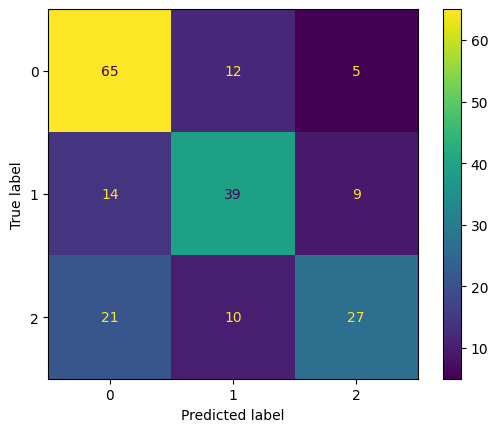

Accuracy:  0.6485148514851485
Precision:  0.6492936158869785
Recall:  0.629077475424365
F1-score:  0.6312955337345582 



In [125]:
import matplotlib.pyplot as plt


matrix = confusion_matrix(dev_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()
plt.show()

print("Accuracy: ", accuracy)
print("Precision: ", results[0])
print("Recall: ", results[1])
print("F1-score: ", results[2], "\n")

**Resultados**:

Partiendo de la matriz de confusión, notamos un claro desbalance entre las predicciones realizadas por clase, donde las clases 0 y 1, correspondientes a las etiquetas Neg y Pos, se predijeron con más éxito que la clase 2, correspondiente a la etiqueta Neu. Una posible explicación de esto es que las tuplas de entrenamiento que están algo desbalanceadas y la clase Neu es minoritaria.\
\
En cuanto a los valores de performance, se ve un claro aumento de rendimiento con respecto a la red sin entrenar. Sin embargo, tampoco se alcanza una gran tasa de predicción correcta: aproximadamente 2 de cada 3 ejemplos se predijeron de manera acertada. Por último, observamos que los valores de las métricas Precision, Recall y F1 están muy cercanos entre sí.

**Descripción del modelo**:

En la Parte 3 realizaremos una búsqueda más profunda entre las opciones posibles para los hiperparámetros de la red.
A pesar de esto, podemos describir la arquitectura de la mejor red obtenida en la Parte 2 compuesta por:
- La capa de entrada que es de tamaño igual a los embeddings utilizados.
- Una capa oculta de 150 nodos con función de activación ReLU.
- La capa de salida con cantidad de nodos igual a clasificaciones posibles por tweet, en este caso 3.

**Experimentos adicionales:** Durante el desarrollo del modelo probamos varias variantes con el objetivo de mejorar el rendimiento, pero no se observaron mejoras significativas:
- Pooling alternativo: Implementamos funciones de average pooling y max pooling para obtener los vectores de los textos. Sin embargo, la diferencia en desempeño fue mínima respecto al promedio simple utilizado en la versión final. Por esta razón, comentamos el código de estos experimentos.
- Stop words: Evaluamos eliminar stopwords, pero tampoco se observaron mejoras. De hecho, en algunos casos el rendimiento disminuyó ligeramente, posiblemente porque algunas stopwords aportan contexto útil para el sentimiento. Por lo tanto, dejamos la lista de stopwords en `None`.
- Funciones de activación: Finalmente, para experimentar con otras funciones de activación como tanh, sigmoid, GELU y LeakyReLU definimos `build_mlp` que construye un modelo con la función de activación que corresponda. Nuevamente, no logramos mejoras respecto a la activación ReLU, que se mantuvo en el modelo final. Por esta razón, comentamos el código de estos experimentos.

En consecuencia, se mantuvo la configuración más simple: average pooling, sin eliminación de stopwords y con activación ReLU, por presentar resultados similares con menor complejidad y tiempo de cómputo.

---

"_Repita el paso anterior, utilizando la misma arquitectura, pero cambiando los embeddings utilizados. Compare los resultados y comente._"

---

Para realizar el cambio de embeddings utilizaremos aquellos extraídos de Wikipedia en HuggingFace:

In [126]:
from gensim.models import KeyedVectors
from huggingface_hub import hf_hub_download
wv = KeyedVectors.load_word2vec_format(hf_hub_download(repo_id="Word2vec/wikipedia2vec_eswiki_20180420_100d", filename="eswiki_20180420_100d.txt"))
print(wv.vectors.shape)
embeddings_size = wv.vectors.shape[1]

(1828809, 100)


Volvemos a construir los conjuntos de train, dev y test pero ahora con los nuevos embeddings.

**Antes de reconstruir dichos conjuntos, también es necesario volver a ejecutar la celda que tiene declarada la función de get_matrix para que pueda ser compatible con los nuevos embeddings.** Repetimos este código a continuación para más claridad.

In [127]:
import string
import random

def l2norm(v, eps=1e-12):
    n = norm(v)
    return v / (n + eps)

# En caso de querer usar stop words
def should_keep(token, stop_words_set=None):
    if stop_words_set is None:
        return True
    return token.lower() not in stop_words_set

punct_vector= np.random.rand(embeddings_size)
num_vector = wv['cinco']

def get_vector(word, wv):
  if word in wv:
    return wv[word]
  elif word.lower() in wv:
    return wv[word.lower()]
  elif word[0] in string.punctuation:
    return punct_vector
  elif word[0] in [0,1,2,3,4,5,6,7,8,9]:
    return num_vector
  else:
    return None

# Definimos dos funciones para aplicar pooling que devuelve un vector representativo del tweet,
# calculando el promedio o máximo de los embeddings de sus palabras.

# Average pooling
def pooling_mean(tokens, wv, stop_words=None, norm_words=True, norm_sent=True):
    vs = []
    for t in tokens:
        if not should_keep(t, stop_words):
            continue
        v = get_vector(t, wv)
        if v is None:
            continue
        vs.append(l2norm(v) if norm_words else v)
    if not vs:
        return np.zeros(wv.vector_size, dtype=np.float32)
    sent = np.mean(vs, axis=0)
    return (l2norm(sent) if norm_sent else sent).astype(np.float32)

# Max pooling
def pooling_max(tokens, wv, stop_words=None, norm_words=True):
    vs = []
    for t in tokens:
        if not should_keep(t, stop_words):
            continue
        v = get_vector(t, wv)
        if v is None:
            continue
        vs.append(l2norm(v) if norm_words else v)
    if not vs:
        return np.zeros(wv.vector_size, dtype=np.float32)
    M = np.stack(vs)
    max_v = np.max(M, axis=0)
    return max_v.astype(np.float32)

# Luego, a partir de una lista de tweets la función 'get_matrix' devuelve
# una matriz con un vector corresondiente a cada tweet
# Para ello recorre los tweets y obtiene la representación de cada token
# Finalmente, promedia sus valores en un único embedding final

def get_matrix(tokens):
  found = 0
  not_found = 0
  zero = np.zeros(embeddings_size)
  vectors = []
  for toks in tokens:
    vs = []
    for t in toks:
      v = get_vector(t, wv)
      if v is not None:
        found += 1
        vs.append(v)
      else:
        not_found += 1
    if len(vs) > 0:
        avg_vector = np.mean(vs, axis=0)
        vectors.append(avg_vector)
    else:
        vectors.append(zero)
  return np.array(vectors)

# Si usamos pooling y stop words, esta función quedaría así:
# def get_matrix(tokens_list, wv, pooling="mean", stop_words=None):
#     if pooling == "mean":
#         M = np.stack([pooling_mean(toks, wv, stop_words=stop_words) for toks in tokens_list])
#         return M.astype(np.float32)
#     elif pooling == "max":
#         M = np.stack([pooling_max(toks, wv, stop_words=stop_words) for toks in tokens_list])
#         return M.astype(np.float32)
#     else:
#         raise ValueError(f"Pooling no soportado: {pooling}. Usar 'mean' o 'max'.")

# Y después la usaríamos así:
# train_emb = torch.tensor(get_matrix(train_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)
# dev_emb = torch.tensor(get_matrix(dev_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)
# test_emb = torch.tensor(get_matrix(test_tokens, wv, pooling = 'idf', stop_words = stop_words_for_emb), dtype=torch.float)

In [128]:
train_emb = torch.tensor(get_matrix(train_tokens), dtype=torch.float)
dev_emb = torch.tensor(get_matrix(dev_tokens), dtype=torch.float)
test_emb = torch.tensor(get_matrix(test_tokens), dtype=torch.float)

print(train_emb.shape)
print(dev_emb.shape)
print(test_emb.shape)

torch.Size([806, 100])
torch.Size([202, 100])
torch.Size([253, 100])


Con el cambio realizado, pasamos nuevamente por la etapa de entrenamiento y evaluación de la red, pero ahora con los conjuntos declarados con los nuevos embeddings.

In [129]:
mlp3 = MLP3(dim_input=embeddings_size, dim_hidden=150, dim_out=len(POLARITY_LABELS), second_layer=False)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp3.parameters(), lr=0.01)

for epoch in range(35):
  optimizer.zero_grad()
  predicted_labels = mlp3.forward(train_emb)
  loss = loss_fn(predicted_labels, torch.tensor(train_labels))
  loss.backward()
  optimizer.step()
  if ((epoch + 1) % 5 == 0):
    print("Época ", epoch + 1, " Loss = ", loss.item())

predicted_labels = evaluate(mlp3, dev_emb)
results = precision_recall_fscore_support(dev_labels, predicted_labels, average='macro', zero_division=0.0)
accuracy = accuracy_score(dev_labels, predicted_labels)

print("Accuracy: ", accuracy)
print("Precision: ", results[0])
print("Recall: ", results[1])
print("F1-score: ", results[2])

Época  5  Loss =  1.0498359203338623
Época  10  Loss =  0.9983659982681274
Época  15  Loss =  0.929947018623352
Época  20  Loss =  0.8673011660575867
Época  25  Loss =  0.8326320648193359
Época  30  Loss =  0.7997627258300781
Época  35  Loss =  0.7784164547920227
Accuracy:  0.5396039603960396
Precision:  0.5464105156723963
Recall:  0.5368521482767664
F1-score:  0.5302861934851554


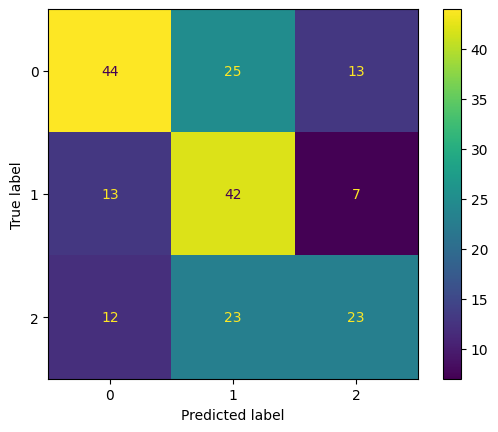

In [130]:
matrix = confusion_matrix(dev_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()
plt.show()

**Comentarios**:

Luego de entrenar y evaluar en el conjunto dev la arquitectura anterior con la segunda opción de embeddings, obtuvimos resultados de menor calidad en comparación con la primer representación. A pesar de esto, la diferencia entre ambos no fue demasiado grande, lo que puede significar que no se precisarían de muchos cambios sobre la arquitectura para adaptarla de mejor manera para estos embeddings. Por ejemplo, una posibilidad sería cambiar la cantidad de nodos de la capa oculta o utilizar una segunda capa.\
\
Una observación a destacar es que el balance entre clases predichas de manera correcta se mantuvo igual a la primer representación, donde los tweets Negativos y Positivos se predijeron mejor que los tweets Neutros.\
\
Finalmente, también concluímos que podría tener cierta influencia la diferencia de tamaño entre ambas representaciones, siendo de tamaño 300 la primera y tamaño 100 la segunda.

## Parte 3 (opcional):
Elija uno de los clasificadores anteriores y realice una búsqueda automatizada de hiperparámetros del modelo. Por ejemplo, puede utilizar una búsqueda en grilla completa o una búsqueda aleatoria, eligiendo diferente cantidad de capas, número unidades por capa, funciones de activación, y valores de learning rate. Intente encontrar el mejor clasificador posible, comparándolos sobre el corpus de **dev**.

---

Realizaremos una búsqueda de hiperparámetros óptimos entre las combinaciones de valores posibles para la tasa de aprendizaje, cantidad de nodos por capa, cantidad de capas, cantidad de épocas y aplicaciones de dropout y weight decays. Para esto, utilizaremos el modelo `mlp3` con tamaño de embedding 300.

In [131]:
learning_rate = [0.02, 0.01, 0.005]
nodos_por_capa = [100, 150, 200]
dos_capas = [False, True]
epocas = [10, 20, 35, 50]
dropouts = [0.0, 0.2, 0.5]
weight_decays = [0.0, 1e-4, 1e-3]

In [132]:
mejor_accuracy = 0
mejor_F1_score = 0
mejor_learning_rate = None
mejor_cantidad_de_nodos = None
mejor_cantidad_de_capas = None
mejor_cantidad_de_epocas = None
mejor_dropout = 0
mejor_weight_decay = 0

# Aseguramos que el tamaño de entrada coincida con la forma de los tensores de entrenamiento
input_dim_actual = train_emb.shape[1]

for paso_aprendizaje in learning_rate:
  for nodos in nodos_por_capa:
    for multiples_capas in dos_capas:
      for epoca in epocas:
        for dropout in dropouts:
          for wd in weight_decays:
            # Usamos input_dim_actual derivado directamente de train_emb
            mlp3 = MLP3(dim_input=input_dim_actual, dim_hidden=nodos, dim_out=len(POLARITY_LABELS), second_layer=multiples_capas, dropout=dropout)
            optimizer = torch.optim.Adam(mlp3.parameters(), lr=paso_aprendizaje, weight_decay=wd)
            loss_fn = torch.nn.CrossEntropyLoss()

            for epoch in range(epoca):
              optimizer.zero_grad()
              predicted_labels = mlp3.forward(train_emb)
              loss = loss_fn(predicted_labels, torch.tensor(train_labels))
              loss.backward()
              optimizer.step()

            predicted_labels = evaluate(mlp3, dev_emb)
            results = precision_recall_fscore_support(dev_labels, predicted_labels, average='macro', zero_division=0.0)
            accuracy = accuracy_score(dev_labels, predicted_labels)

            if accuracy >= mejor_accuracy:
              mejor_accuracy = accuracy
              mejor_learning_rate = paso_aprendizaje
              mejor_cantidad_de_nodos = nodos
              if multiples_capas:
                mejor_cantidad_de_capas = 2
              else:
                mejor_cantidad_de_capas = 1
              mejor_cantidad_de_epocas = epoca
              mejor_dropout = dropout
              mejor_weight_decay = wd

print("Mejor precisión alcanzada: ", mejor_accuracy)
print("Mejor dropout: ", mejor_dropout)
print("Mejor weight decay: ", mejor_weight_decay)

Mejor precisión alcanzada:  0.6188118811881188
Mejor dropout:  0.0
Mejor weight decay:  0.0001


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1. Incluya también una matriz de confusión.

Accuracy alcanzado:  0.6188118811881188 

Mejor tasa de aprendizaje alcanzada:  0.005
Mejor cantidad de nodos alcanzada:  200
Mejor cantidad de capas alcanzada:  1
Mejor cantidad de epocas alcanzada:  35
Mejor valor de dropout alcanzado:  0.0
Mejor valor de weight decay alcanzado:  0.0001 

Macro-Precision:  0.5817107430010656
Macro-Recall:  0.5634942166996754
Macro-F1:  0.5557265598012627 

Matriz de confusión: 



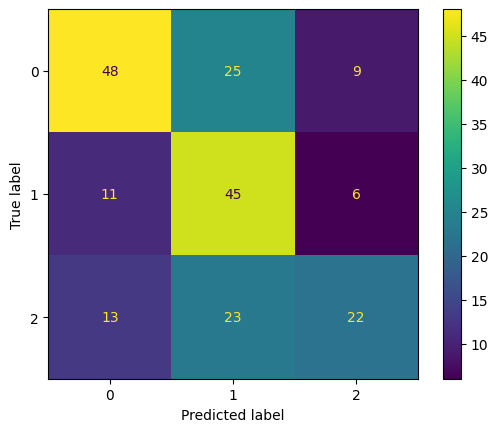

In [133]:
print("Accuracy alcanzado: ", mejor_accuracy, "\n")

print("Mejor tasa de aprendizaje alcanzada: ", mejor_learning_rate)
print("Mejor cantidad de nodos alcanzada: ", mejor_cantidad_de_nodos)
print("Mejor cantidad de capas alcanzada: ", mejor_cantidad_de_capas)
print("Mejor cantidad de epocas alcanzada: ", mejor_cantidad_de_epocas)
print("Mejor valor de dropout alcanzado: ", mejor_dropout)
print("Mejor valor de weight decay alcanzado: ", mejor_weight_decay, "\n")

print("Macro-Precision: ", results[0])
print("Macro-Recall: ", results[1])
print("Macro-F1: ", results[2], "\n")
print("Matriz de confusión: \n")

matrix = confusion_matrix(dev_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()
plt.show()

## Parte 4:

Elija el mejor clasificador de todos los construidos en las partes anteriores, comparándolos utilizando la medida macro-F1, y evalúelo sobre el corpus de **test**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1.

Realizamos la evaluación en el conjunto test con el modelo `mlp3`, utilizando los hiperparámetros óptimos obtenidos en la Parte 3.

In [134]:
mlp3 = MLP3(dim_input=embeddings_size, dim_hidden=mejor_cantidad_de_nodos, dim_out=len(POLARITY_LABELS), second_layer=(mejor_cantidad_de_capas == 2), dropout=mejor_dropout)
optimizer = torch.optim.Adam(mlp3.parameters(), lr=mejor_learning_rate, weight_decay=mejor_weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(mejor_cantidad_de_epocas):
  optimizer.zero_grad()
  predicted_labels = mlp3.forward(test_emb)
  loss = loss_fn(predicted_labels, torch.tensor(test_labels))
  loss.backward()
  optimizer.step()

predicted_labels = evaluate(mlp3, test_emb)
accuracy = accuracy_score(test_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='macro', zero_division=0.0)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", f1)


Accuracy:  0.766798418972332
Precision:  0.76709358213175
Recall:  0.7401798988997919
F1-score:  0.750073414203924


Despliege la matriz de confusión sobre el corpus de **test** para las tres clases (P, N, NEU) para el mejor clasificador construido en las partes anteriores.

Matríz de confusión:



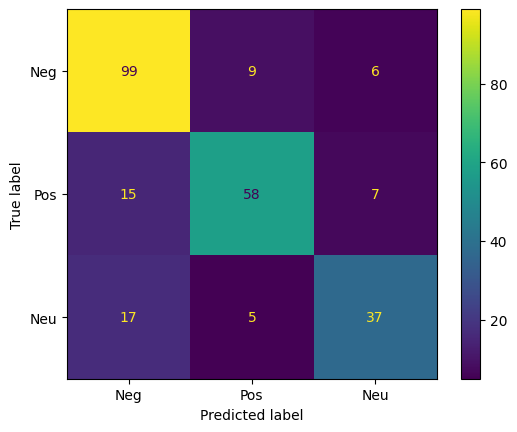

In [135]:
print("Matríz de confusión:\n")
matrix = confusion_matrix(test_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=POLARITY_LABELS)
disp.plot()
plt.show()

Analice los resultados, y responda, al menos, las siguientes preguntas:

1.   ¿Cuál fue la representación que funcionó mejor? Describa brevemente sus características.
2.   ¿Cuál es la forma del modelo? Indique cantidad de capas, unidades, y funciones de activación. Puede usar el método print() sobre el modelo para imprimir la forma del modelo.
3.   Indique qué categoría o categorías fueron las más difíciles de aprender para su clasificador. ¿La categoría más difícil es la misma para el mejor clasificador de las partes 1 y 2 (y la parte 3 si la hizo)?

**Respuestas:**

1. El modelo con mejor rendimiento fue el MLP3 entrenado sobre una representación basada en embeddings preentrenados SBW. Estos embeddings tienen 300 dimensiones y fueron obtenidos mediante el promedio (average pooling) de los vectores de las palabras de cada texto. Esta representación captura relaciones semánticas más ricas que BOW o TF-IDF, permitiendo al modelo generalizar mejor a partir del significado de las palabras.

2. El modelo final fue un MLP con una sola capa oculta, con la siguiente estructura:
  - Entrada	de 300 neuronas, una por dimensión del embedding promedio.
  - Capa oculta con 150 neuronas.
  - Función de activación	ReLU.
  - Salida de 3 neuronas correspondientes a las clases Negativo, Positivo, Neutro.
  - Optimización Adam con learning rate y weight decay ajustados según mejores resultados.
  - Función de pérdida CrossEntropyLoss.
3. La matriz de confusión muestra que el modelo logra distinguir razonablemente entre opiniones positivas, negativas y neutras. A diferencia de las partes anteriores, el modelo no tiene tanta tendencia a confundir las opiniones neutras con las otras dos clases. Sin embargo, al ser la clase minoritaria, el porcentaje de ejemplos mal clasificados para esta clase sigue siendo mayor.

In [136]:
print(mlp3)

MLP3(
  (linear_1): Linear(in_features=100, out_features=200, bias=True)
  (ReLU): ReLU()
  (out): Linear(in_features=200, out_features=3, bias=True)
  (net): Sequential(
    (0): Linear(in_features=100, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=3, bias=True)
  )
)
